In [4]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import json
import pandas as pd
from pathlib import Path
import re

def create_dataframe_from_results_json(spaces_folder):
    """
    Recursively search through spaces folder to find all results.json files
    and create a DataFrame with extracted information.
    
    Args:
        spaces_folder (str): Path to the spaces folder
        
    Returns:
        pd.DataFrame: DataFrame containing data from all results.json files
    """
    # Convert to Path object for easier handling
    spaces_path = Path(spaces_folder)
    
    # Find all results.json files recursively
    json_files = list(spaces_path.glob('**/results.json'))
    
    all_data = []
    
    for json_file in json_files:
        try:
            # Extract path components
            parts = json_file.parts
            
            # Find the index of 'spaces' in the path
            try:
                spaces_index = parts.index('spaces')
            except ValueError:
                # If 'spaces' not in path, use the first element
                spaces_index = 0
            
            # Extract region_function (assuming it's right after 'spaces')
            if spaces_index + 1 < len(parts):
                region_function = parts[spaces_index + 1]
            else:
                region_function = "unknown"
            
            # Split region and function (e.g., "R1-49" into "R1" and "49")
            match = re.match(r'([A-Za-z]+)(\d*)-(\d+)', region_function)
            if match:
                region = match.group(1) + match.group(2)  # R1
                function = match.group(3)                 # 49
            else:
                region = region_function
                function = region_function
            
            # Extract week (assuming it's the directory containing results.json)
            week = parts[-2]
            
            # Load JSON data
            with open(json_file, "r") as f:
                data = json.load(f)
            
            # If data is a dictionary, wrap it in a list
            if isinstance(data, dict):
                data = [data]
            
            # Create DataFrame from this file
            file_df = pd.json_normalize(data)
            
            # Add extracted columns
            file_df["region"] = region
            file_df["function"] = str(function)
            file_df["week"] = week
            file_df["file_path"] = str(json_file)
            
            all_data.append(file_df)
            
        except Exception as e:
            print(f"Error processing {json_file}: {e}")
    
    # Combine all dataframes
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        return final_df
    else:
        print("No valid results.json files found")
        return pd.DataFrame()

# Example usage
df = create_dataframe_from_results_json("spaces")
df


,averageQueueTime,penaltyProportion,averageExecutionTime,averageComputerTime,averageWaitTime,endTime,region,function,week,file_path
0,1.887548,11.809522,0.002162,0.023240,0.0,1203.993279,R1,817,3,spaces/R1-817/validation_results/pipeline-R1-8...
1,2.277217,10.980285,0.001048,0.022125,0.0,1199.947855,R1,817,2,spaces/R1-817/validation_results/pipeline-R1-8...
2,1.566952,10.127198,0.001048,0.022125,0.0,1201.970371,R1,817,0,spaces/R1-817/validation_results/pipeline-R1-8...
3,1.510231,9.452713,0.002015,0.023093,0.0,1199.962801,R1,817,1,spaces/R1-817/validation_results/pipeline-R1-8...
4,2.052952,10.425856,0.001178,0.022256,0.0,1199.976287,R1,1233,3,spaces/R1-1233/validation_results/pipeline-R1-...
5,2.191043,10.978434,0.001915,0.022993,0.0,1199.930818,R1,1233,2,spaces/R1-1233/validation_results/pipeline-R1-...
6,2.193756,11.462729,0.002792,0.023869,0.0,1199.975479,R1,1233,0,spaces/R1-1233/validation_results/pipeline-R1-...
7,2.116844,10.687811,0.002343,0.023421,0.0,1199.934066,R1,1233,1,spaces/R1-1233/validation_results/pipeline-R1-...
8,2.296342,11.339422,0.002028,0.023106,0.0,1200.322269,R1,1437,3,spaces/R1-1437/validation_results/pipeline-R1-...
9,2.032560,10.194532,0.001048,0.022125,0.0,1199.960429,R1,1437,2,spaces/R1-1437/validation_results/pipeline-R1-...


Text(0.5, 0, 'Function')

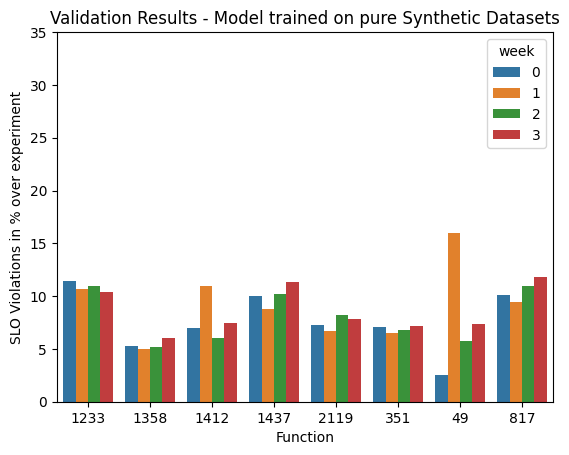

In [18]:
g = sns.barplot(x='function', y='penaltyProportion', hue='week', data=df.sort_values(by=['function', 'week']))
g.set_ylim(0,35)
g.set_title('Validation Results - Model trained on pure Synthetic Datasets')
g.set_ylabel('SLO Violations in % over experiment')
g.set_xlabel('Function')

In [22]:
df.groupby(['week'])['penaltyProportion'].describe()

,count,mean,std,min,25%,50%,75%,max
week,,,,,,,,
0,8.0,7.595706,2.899224,2.512219,6.559001,7.210815,10.008444,11.462729
1,8.0,9.250121,3.439146,4.976679,6.640910,9.124524,10.749642,15.973221
2,8.0,8.015208,2.417974,5.224361,5.957996,7.490962,10.390507,10.980285
3,8.0,8.674019,2.175886,6.064409,7.294752,7.624767,10.654248,11.809522


In [23]:
import pandas as pd
from pathlib import Path
import re

def calculate_statistics_from_system_events(spaces_folder):
    """
    Recursively search through spaces folder to find all system_events.csv files,
    read them as DataFrames, and calculate comprehensive statistics for 'count' and 'average_queue_length'.
    Also extracts region, function, and week from the file path.

    Args:
        spaces_folder (str): Path to the spaces folder

    Returns:
        pd.DataFrame: DataFrame containing statistics for each file with path information
    """
    # Convert to Path object for easier handling
    spaces_path = Path(spaces_folder)
    
    # Find all system_events.csv files recursively
    csv_files = list(spaces_path.glob('**/system_events.csv'))
    
    results = []
    
    for csv_file in csv_files:
        try:
            # Extract path components
            parts = csv_file.parts
            
            # Find the index of 'spaces' in the path
            try:
                spaces_index = parts.index('spaces')
            except ValueError:
                # If 'spaces' not in path, use the first element
                spaces_index = 0
            
            # Extract region_function (assuming it's right after 'spaces')
            if spaces_index + 1 < len(parts):
                region_function = parts[spaces_index + 1]
            else:
                region_function = "unknown"
            
            # Split region and function (e.g., "R1-49" into "R1" and "49")
            match = re.match(r'([A-Za-z]+)(\d*)-(\d+)', region_function)
            if match:
                region = match.group(1) + match.group(2)  # R1
                function = match.group(3)                 # 49
            else:
                region = region_function
                function = region_function
            
            # Extract week (assuming it's the directory containing system_events.csv)
            week = parts[-2]
            
            # Read the CSV file into a DataFrame
            df = pd.read_csv(csv_file)
            
            # Calculate statistics for count
            count_mean = df['count'].mean()
            count_min = df['count'].min()
            count_max = df['count'].max()
            count_std = df['count'].std()
            count_median = df['count'].median()
            
            # Calculate statistics for average_queue_length
            queue_mean = df['average_queue_length'].mean()
            queue_min = df['average_queue_length'].min()
            queue_max = df['average_queue_length'].max()
            queue_std = df['average_queue_length'].std()
            queue_median = df['average_queue_length'].median()
            
            # Append results
            results.append({
                'file_path': str(csv_file),
                'region': region,
                'function': function,
                'week': week,
                'count_mean': count_mean,
                'count_min': count_min,
                'count_max': count_max,
                'count_std': count_std,
                'count_median': count_median,
                'queue_mean': queue_mean,
                'queue_min': queue_min,
                'queue_max': queue_max,
                'queue_std': queue_std,
                'queue_median': queue_median
            })
        except Exception as e:
            print(f"Error processing {csv_file}: {e}")
    
    # Convert results to a DataFrame
    if results:
        final_df = pd.DataFrame(results)
        return final_df
    else:
        print("No valid system_events.csv files found")
        return pd.DataFrame()

# Example usage
system_events_df = calculate_statistics_from_system_events("spaces")
system_events_df


,file_path,region,function,week,count_mean,count_min,count_max,count_std,count_median,queue_mean,queue_min,queue_max,queue_std,queue_median
0,spaces/R1-817/validation_results/pipeline-R1-8...,R1,817,3,9.444444,4,18,3.416870,9.0,16.291381,0.0,400.166667,68.788843,0.142857
1,spaces/R1-817/validation_results/pipeline-R1-8...,R1,817,2,15.087500,9,20,2.705801,15.5,24.186050,0.0,670.555556,111.062614,0.146429
2,spaces/R1-817/validation_results/pipeline-R1-8...,R1,817,0,8.987654,5,10,1.336916,10.0,22.350632,0.0,629.500000,100.905677,0.125000
3,spaces/R1-817/validation_results/pipeline-R1-8...,R1,817,1,10.975000,7,19,2.796811,10.0,24.116204,0.0,636.700000,106.242210,0.200000
4,spaces/R1-1233/validation_results/pipeline-R1-...,R1,1233,3,10.550000,8,12,1.101208,11.0,26.713324,0.0,627.583333,112.884830,0.174242
5,spaces/R1-1233/validation_results/pipeline-R1-...,R1,1233,2,10.387500,8,12,1.084923,10.0,28.159495,0.0,714.250000,125.192880,0.174242
6,spaces/R1-1233/validation_results/pipeline-R1-...,R1,1233,0,10.625000,8,12,0.985657,11.0,31.890038,0.0,732.600000,130.001346,0.181818
7,spaces/R1-1233/validation_results/pipeline-R1-...,R1,1233,1,10.637500,8,14,1.324011,10.0,32.883142,0.0,746.900000,133.926160,0.236364
8,spaces/R1-1437/validation_results/pipeline-R1-...,R1,1437,3,10.827160,6,15,1.766282,10.0,34.283336,0.0,788.000000,141.507108,0.166667
9,spaces/R1-1437/validation_results/pipeline-R1-...,R1,1437,2,11.375000,7,15,1.788677,11.0,20.844773,0.0,635.800000,100.642055,0.090909


Text(0.5, 1.0, 'Resource Usage with model trained on Synthetic Data')

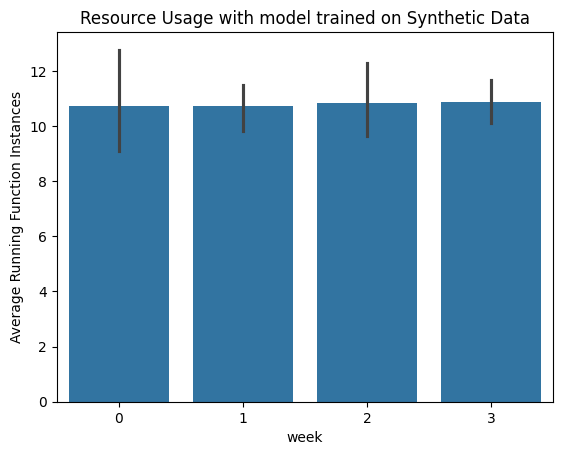

In [28]:
g = sns.barplot( y='count_mean', x='week', data=system_events_df.sort_values(by='week'))
g.set_ylabel("Average Running Function Instances")
g.set_title("Resource Usage with model trained on Synthetic Data")